# SNP vs non-SNP peak discrepancy — *SVs bring new peaks that SNPs missed*

Five visualization **options** for the same claim, on the class-split multi-trait (**JOINT**)
GWAS of the ecotype-selection trait `s`. SNP-only (1.75M markers), non-SNP (indel+SV, 525k), and
strict-SV (12.8k) scans share the trait and the LOCO kinship correction — only the tested marker
class differs. We collapse to **clq0.9 LD blocks** (one lead marker/block) and ask where the
non-SNP / SV scan lights up a block the SNP scan leaves sub-threshold.

**Peak inventory (blocks sig in class but NOT SNP, JOINT contrast):** SV-only = **2/2 Bonferroni,
5/17 FDR** (i.e. *every* strong SV JOINT peak is SNP-invisible); non-SNP-only = 5/10 Bonf, 258/1000
FDR. Union across all 52 contrasts: SV-only 10 Bonf / 17 FDR; non-SNP-only 46 Bonf / 431 FDR.

**Framing caveat (keep honest):** this is a *peak-level* claim and is distinct from the
variance-partition result (non-SNP adds no *polygenic* variance = passengers) and the GO
enrichment (the extra peaks are not a coherent functional class). The defensible story is *"SNPs
capture the polygenic signal, but at specific loci SVs surface peaks the SNP panel leaves
sub-threshold — candidate incomplete-tagging sites."* No chart titles per repo convention.

In [1]:

import os, sys
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl
os.chdir("/global/scratch/users/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_gea")
import lib
DIR = "analysis/grenenet_gea/varexp"
PLOTS = f"{DIR}/gwas_plots"; os.makedirs(PLOTS, exist_ok=True)
CHROM_ORDER = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]
CONTRAST = "p_joint"        # headline = multi-trait JOINT
rng = np.random.default_rng(0)

def load_class(name):
    d = np.load(f"{DIR}/class_gwas_{name}.npz", allow_pickle=True)
    chrom = np.array([c.replace("chr", "Chr") for c in d["chrom"]])
    pos = d["pos"].astype(np.int64)
    nlp = -np.log10(np.clip(d[CONTRAST], 1e-300, 1))
    blk = lib.assign_clq_blocks(chrom, pos, r2=0.9)
    return pd.DataFrame({"chrom": chrom, "pos": pos, "nlp": nlp, "block": blk})

D = {c: load_class(c) for c in ["snp", "nonsnp", "sv"]}
for c, df in D.items():
    print(f"{c:7s} {len(df):>9,} markers, {df.block[df.block!='' ].nunique():>6} blocks")

# ---- genome x-coordinate (offsets from SNP chrom spans; small gap between chroms) ----
chrom_len = {c: int(D["snp"].pos[D["snp"].chrom == c].max()) for c in CHROM_ORDER}
GAP = int(2e6)
offset, cum = {}, 0
for c in CHROM_ORDER:
    offset[c] = cum; cum += chrom_len[c] + GAP
ticks = [offset[c] + chrom_len[c] / 2 for c in CHROM_ORDER]
def gx(chrom, pos):
    return np.array([offset[c] for c in chrom]) + np.asarray(pos)
for c in D:
    D[c]["gx"] = gx(D[c]["chrom"].values, D[c]["pos"].values)

# ---- block leads (one min-p / max-nlp marker per block) + significance per class ----
def block_leads(df):
    d = df[df.block != ""]
    idx = d.groupby("block")["nlp"].idxmax()
    lead = d.loc[idx, ["block", "chrom", "pos", "gx", "nlp"]].reset_index(drop=True)
    p = 10.0 ** (-lead["nlp"].to_numpy())
    lead["q"] = lib.bh(p)
    lead["bonf"] = p < 0.05 / len(p)
    lead["fdr"] = lead["q"] < 0.05
    lead["p"] = p
    return lead

L = {c: block_leads(D[c]) for c in D}
BONF = {c: -np.log10(0.05 / len(L[c])) for c in D}       # per-class Bonferroni line (block-level)
print("\nBonferroni -log10p line:", {c: round(BONF[c], 2) for c in D})
print("blocks Bonf/FDR sig:", {c: (int(L[c].bonf.sum()), int(L[c].fdr.sum())) for c in D})

# ---- "class-only" blocks: sig in class but not SNP ----
def class_only(cls, tier):
    col = "bonf" if tier == "bonf" else "fdr"
    csig = set(L[cls].loc[L[cls][col], "block"])
    ssig = set(L["snp"].loc[L["snp"][col], "block"])
    return L[cls][L[cls].block.isin(csig - ssig)].copy()

SVONLY = {t: class_only("sv", t) for t in ["bonf", "fdr"]}
NSONLY = {t: class_only("nonsnp", t) for t in ["bonf", "fdr"]}
print("SV-only  (JOINT):", {t: len(SVONLY[t]) for t in SVONLY})
print("nonSNP-only(JOINT):", {t: len(NSONLY[t]) for t in NSONLY})

# ---- gene label for a genomic position (overlapping gene symbol, else nearest) ----
GENES = lib.load_genes()
def gene_at(chrom, pos):
    g = GENES[GENES.chrom == chrom]
    ov = g[(g.start <= pos) & (g.end >= pos)]
    if len(ov):
        r = ov.iloc[0]
    else:
        r = g.iloc[(g.start - pos).abs().argsort().iloc[0]]
    sym = r["name"] if isinstance(r["name"], str) and r["name"] else r["gene"]
    return sym
for t in ["bonf", "fdr"]:
    SVONLY[t]["gene"] = [gene_at(c, p) for c, p in zip(SVONLY[t].chrom, SVONLY[t].pos)]
    NSONLY[t]["gene"] = [gene_at(c, p) for c, p in zip(NSONLY[t].chrom, NSONLY[t].pos)]

CCOL = {"Chr1": "#3A5A98", "Chr2": "#AEBDD6", "Chr3": "#3A5A98", "Chr4": "#AEBDD6", "Chr5": "#3A5A98"}
SVC, NSC = "#E07A5F", "#E07A5F"     # SNP = blue family; the compared class = terracotta accent
def chrom_colors(df): return [CCOL[c] for c in df.chrom]
print("\nsetup done.")


snp     1,752,846 markers,  57768 blocks
nonsnp    525,043 markers,  44137 blocks
sv         12,789 markers,   4874 blocks



Bonferroni -log10p line: {'snp': 6.06, 'nonsnp': 5.95, 'sv': 4.99}
blocks Bonf/FDR sig: {'snp': (14, 8269), 'nonsnp': (10, 1000), 'sv': (2, 17)}
SV-only  (JOINT): {'bonf': 2, 'fdr': 5}
nonSNP-only(JOINT): {'bonf': 5, 'fdr': 258}



setup done.


## Option 1 — Mirror Manhattan (SNP up ↑ / SV down ↓)

The classic two-GWAS comparison. SNP −log10p points **up**, SV points **down**, shared genomic
x-axis. An **SV-only peak = a downward spike with no upward counterpart** (annotated with its
gene). Because SV markers are sparse (12.8k), the bottom track is naturally uncluttered — which is
the point: SVs are rare but bring these specific new peaks. Dashed lines = block-level Bonferroni.

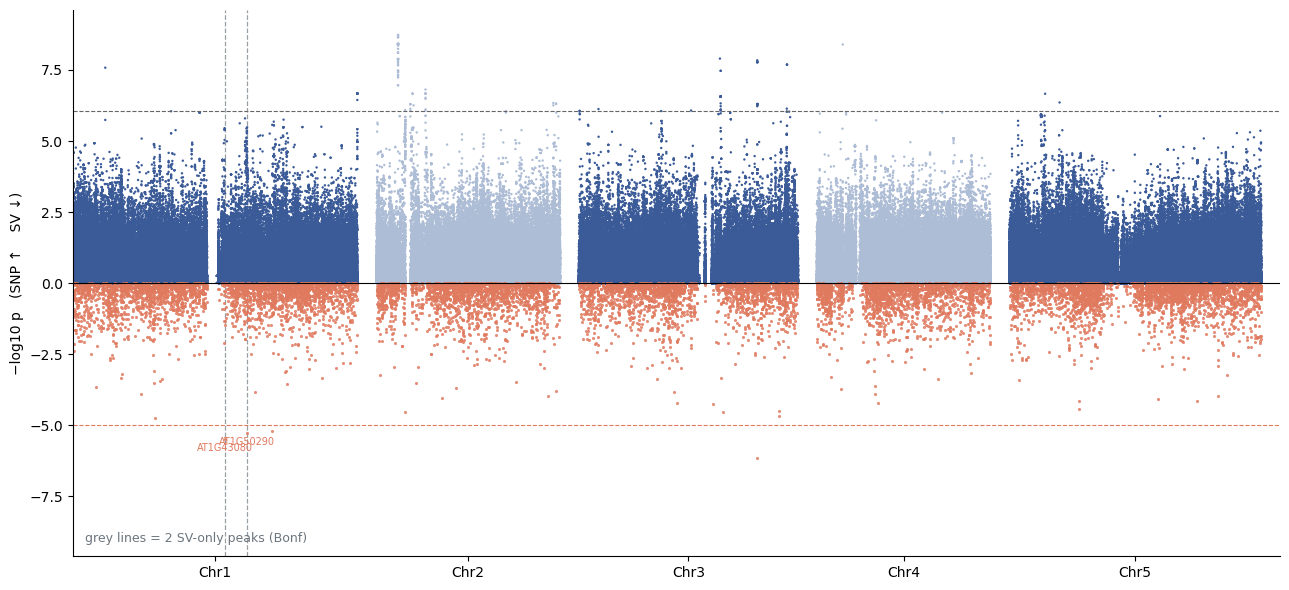

In [2]:

def mirror(bottom, bcol, bonly, tag, fname):
    fig, ax = plt.subplots(figsize=(13, 6))
    # grey vertical lines at the class-only peaks (behind points) -- eyeball SNP signal there
    for _, r in bonly.iterrows():
        ax.axvline(r.gx, color="#6c757d", lw=0.9, ls="--", alpha=0.7, zorder=0)
    # SNP up: ALL markers (no subsample -> no density-edge band)
    s = D["snp"]
    ax.scatter(s.gx, s.nlp, s=3, c=chrom_colors(s), rasterized=True, linewidths=0, zorder=2)
    # bottom class: all markers, mirrored (negative)
    b = D[bottom]
    ax.scatter(b.gx, -b.nlp, s=5, c=bcol, rasterized=True, linewidths=0, alpha=0.85, zorder=2)
    ax.axhline(BONF["snp"], ls="--", lw=.8, c="0.4"); ax.axhline(-BONF[bottom], ls="--", lw=.8, c=bcol)
    ax.axhline(0, lw=.8, c="k")
    for _, r in bonly.iterrows():
        ax.annotate(r.get("gene", ""), (r.gx, -r.nlp), fontsize=7, ha="center", va="top",
                    xytext=(0, -3), textcoords="offset points", color=bcol)
    ax.set_xticks(ticks); ax.set_xticklabels(CHROM_ORDER)
    ax.set_ylabel("−log10 p   (SNP ↑    %s ↓)" % tag)
    ax.set_xlim(0, cum); yl = max(s.nlp.max(), b.nlp.max()) * 1.1
    ax.set_ylim(-yl, yl)
    ax.annotate(f"grey lines = {len(bonly)} {tag}-only peaks (Bonf)", (0.01, 0.02),
                xycoords="axes fraction", fontsize=9, color="#6c757d", va="bottom")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout(); fig.savefig(f"{PLOTS}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

mirror("sv", SVC, SVONLY["bonf"], "SV", "mirror_manhattan_snp_vs_sv.png")


### Option 1b — same, but SNP ↑ / non-SNP (indel+SV) ↓

Denser bottom track (525k markers, 46 non-SNP-only Bonferroni peaks) — more convincing visually,
but the headline becomes "non-SNP variation" rather than "SVs" specifically.

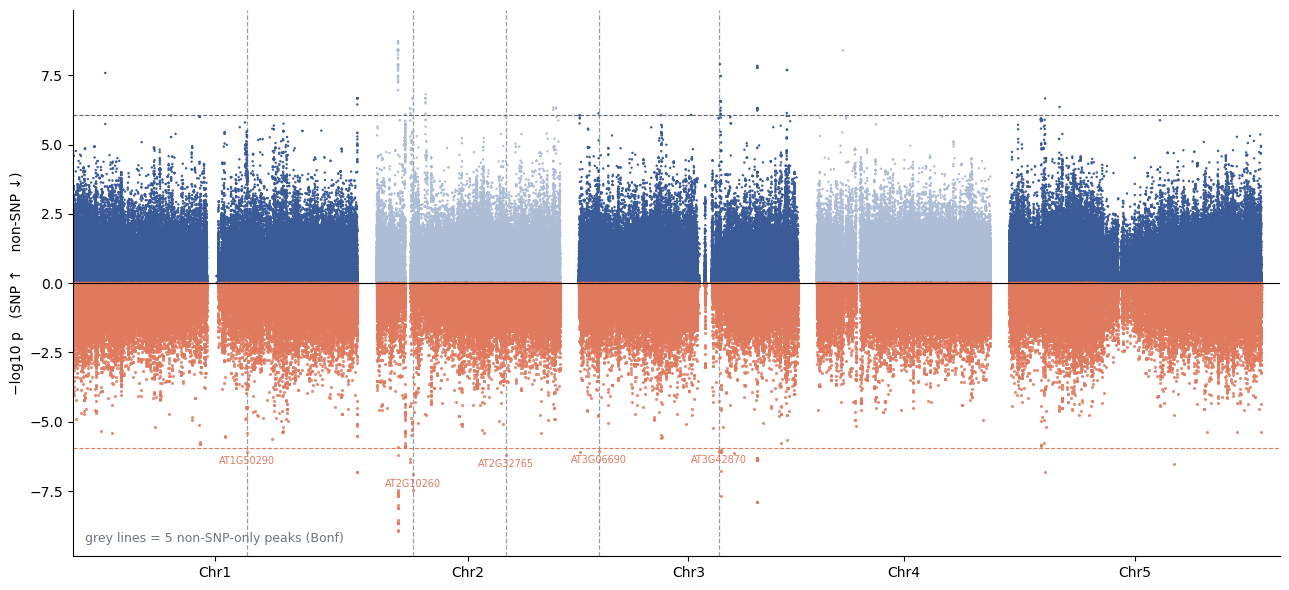

In [3]:
mirror("nonsnp", NSC, NSONLY["bonf"], "non-SNP", "mirror_manhattan_snp_vs_nonsnp.png")

## Option 2 — Overlaid Manhattan (SNP grey cloud, SV bold points on top)

Both classes on one upward axis: SNP as a faint grey cloud, SV as bold orange points drawn on
top. An **SV-only peak = an orange point rising above the grey SNP baseline** where no grey point
reaches. Circles ring the SV-only Bonferroni peaks.

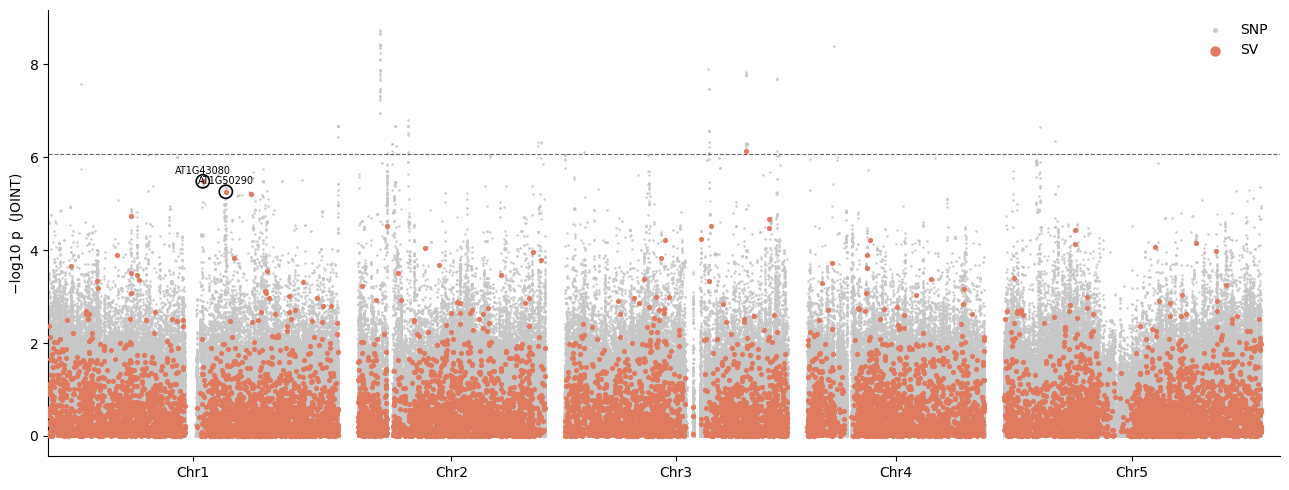

In [4]:

fig, ax = plt.subplots(figsize=(13, 5))
s = D["snp"]
ax.scatter(s.gx, s.nlp, s=3, c="0.78", rasterized=True, linewidths=0, label="SNP")
ax.scatter(D["sv"].gx, D["sv"].nlp, s=14, c=SVC, linewidths=0, label="SV", zorder=3)
ax.scatter(SVONLY["bonf"].gx, SVONLY["bonf"].nlp, s=90, facecolors="none",
           edgecolors="k", linewidths=1.2, zorder=4)
for _, r in SVONLY["bonf"].iterrows():
    ax.annotate(r.gene, (r.gx, r.nlp), fontsize=7, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")
ax.axhline(BONF["snp"], ls="--", lw=.8, c="0.4")
ax.set_xticks(ticks); ax.set_xticklabels(CHROM_ORDER); ax.set_xlim(0, cum)
ax.set_ylabel("−log10 p  (JOINT)"); ax.legend(loc="upper right", frameon=False, markerscale=2)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig(f"{PLOTS}/overlay_manhattan_snp_sv.png", dpi=150, bbox_inches="tight"); plt.show()


## Option 3 — Differential Manhattan (per-block Δ −log10p)

The most *direct* encoding of "what the class adds". For every clq0.9 block present in both scans,
Δ = (class lead −log10p) − (SNP lead −log10p), plotted along the genome. **Upward orange spikes =
the SV scan is stronger there (new peaks); downward grey = SNP-stronger.** Isolates the discrepancy
and shows it is largely two-sided noise with a few genuine SV-adds.

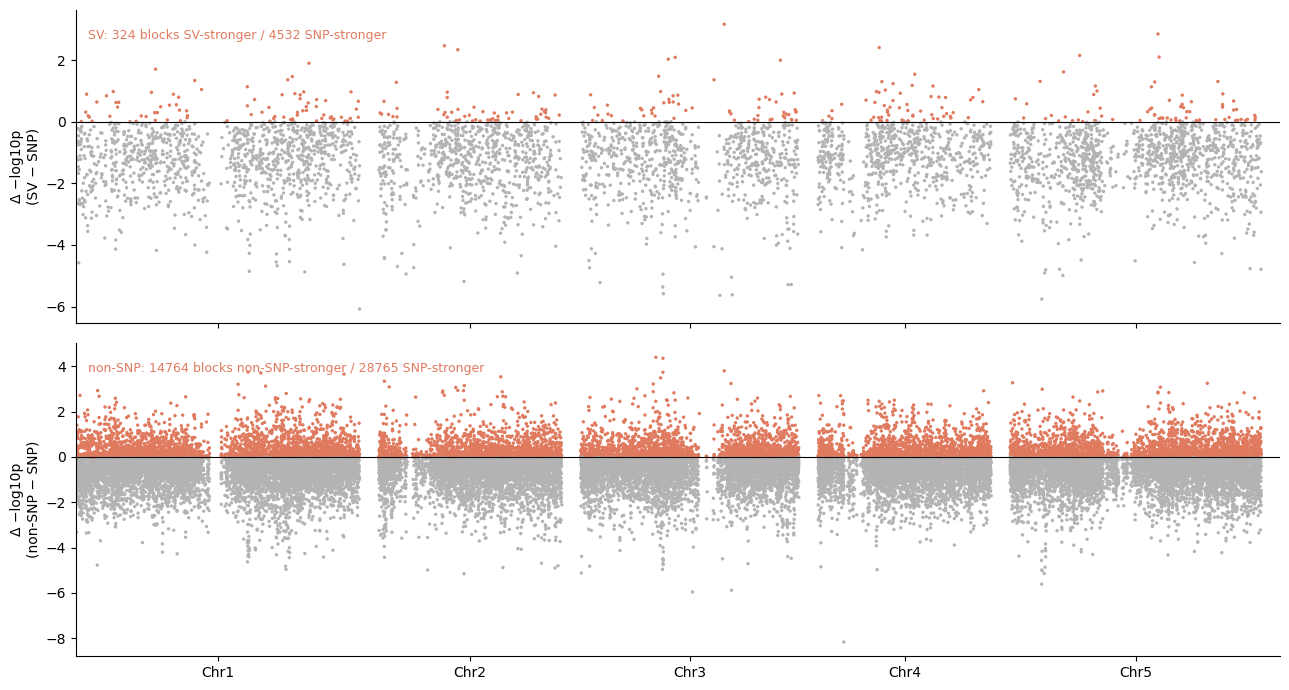

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, (cls, col, tag) in zip(axes, [("sv", SVC, "SV"), ("nonsnp", NSC, "non-SNP")]):
    m = L[cls].merge(L["snp"][["block", "nlp"]], on="block", suffixes=("", "_snp"))
    m["d"] = m.nlp - m.nlp_snp
    ax.scatter(m.gx, m.d, s=6, c=np.where(m.d > 0, col, "0.7"), rasterized=True, linewidths=0)
    ax.axhline(0, lw=.8, c="k")
    ax.set_xticks(ticks); ax.set_xticklabels(CHROM_ORDER); ax.set_xlim(0, cum)
    ax.set_ylabel(f"Δ −log10p\n({tag} − SNP)")
    ax.annotate(f"{tag}: {(m.d>0).sum()} blocks {tag}-stronger / {(m.d<0).sum()} SNP-stronger",
                (0.01, 0.94), xycoords="axes fraction", fontsize=9, va="top", color=col)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig(f"{PLOTS}/differential_manhattan.png", dpi=150, bbox_inches="tight"); plt.show()


## Option 4 — Concordance scatter (per-block lead −log10p)

Each dot = one clq0.9 block; x = SNP lead −log10p, y = SV (left) / non-SNP (right) lead −log10p.
**Most blocks sit on the diagonal (shared backbone); the SV/non-SNP-only peaks are the coloured
points in the upper-left** (strong in the class, weak in SNP). This is the honest quantification —
it shows the concordance *and* the class-unique outliers in one view. Grey lines = Bonferroni.

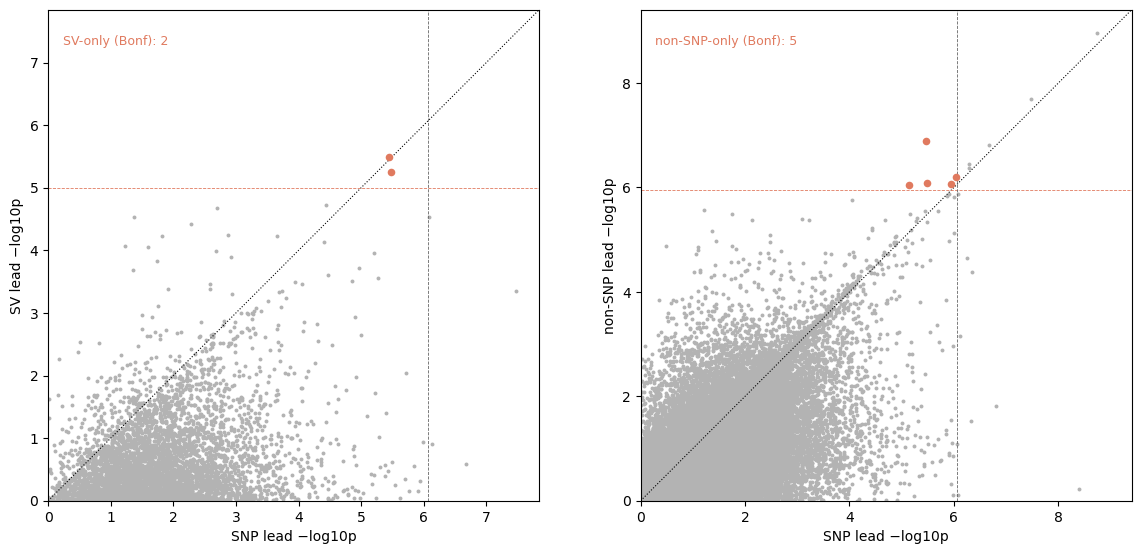

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, (cls, col, tag, only) in zip(axes, [("sv", SVC, "SV", SVONLY), ("nonsnp", NSC, "non-SNP", NSONLY)]):
    m = L[cls].merge(L["snp"][["block", "nlp"]], on="block", suffixes=("", "_snp"))
    onlyset = set(only["bonf"].block)
    isonly = m.block.isin(onlyset)
    ax.scatter(m.nlp_snp[~isonly], m.nlp[~isonly], s=8, c="0.7", linewidths=0, rasterized=True)
    ax.scatter(m.nlp_snp[isonly], m.nlp[isonly], s=30, c=col, linewidths=0, zorder=3)
    lim = max(m.nlp.max(), m.nlp_snp.max()) * 1.05
    ax.plot([0, lim], [0, lim], ls=":", c="k", lw=.8)
    ax.axhline(BONF[cls], ls="--", lw=.6, c=col); ax.axvline(BONF["snp"], ls="--", lw=.6, c="0.4")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("SNP lead −log10p"); ax.set_ylabel(f"{tag} lead −log10p")
    ax.annotate(f"{tag}-only (Bonf): {len(only['bonf'])}", (0.03, 0.95), xycoords="axes fraction",
                fontsize=9, va="top", color=col)
    ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(f"{PLOTS}/concordance_scatter.png", dpi=150, bbox_inches="tight"); plt.show()


## Option 5 — Zoom locus panels (top SV-only peaks)

The **proof** panel: for the strongest SV-only Bonferroni peaks (JOINT), a local window (±60 kb
around the block) showing SNP markers (grey) vs SV markers (orange) −log10p, with the gene(s)
underneath. Where the SV spikes and the SNPs are flat, *the SNP scan genuinely had nothing there.*

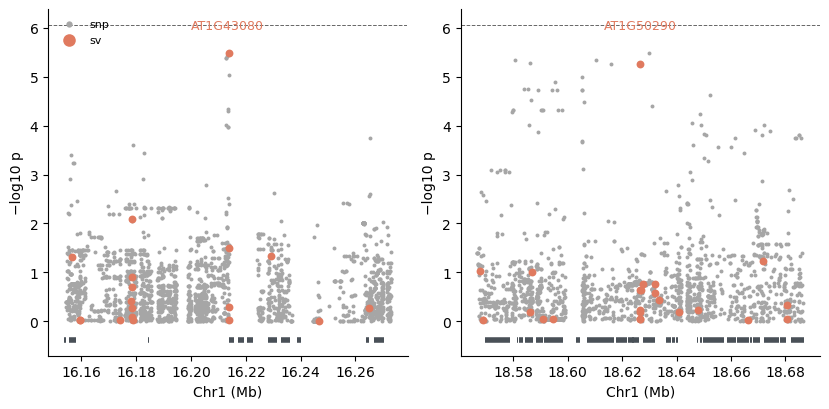

In [7]:

top = SVONLY["bonf"].sort_values("nlp", ascending=False).head(4).reset_index(drop=True)
if len(top) == 0:
    top = SVONLY["fdr"].sort_values("nlp", ascending=False).head(4).reset_index(drop=True)
n = len(top); fig, axes = plt.subplots(1, max(n, 1), figsize=(4.2 * max(n, 1), 4.2), squeeze=False)
axes = axes[0]
PAD = 60_000
for ax, (_, r) in zip(axes, top.iterrows()):
    c = r.chrom; lo, hi = r.pos - PAD, r.pos + PAD
    for cls, col, sz in [("snp", "0.65", 8), ("sv", SVC, 32)]:
        d = D[cls]; w = d[(d.chrom == c) & (d.pos >= lo) & (d.pos <= hi)]
        ax.scatter(w.pos / 1e6, w.nlp, s=sz, c=col, linewidths=0, label=cls, zorder=3 if cls == "sv" else 1)
    ax.axhline(BONF["snp"], ls="--", lw=.7, c="0.4")
    g = GENES[(GENES.chrom == c) & (GENES.start <= hi) & (GENES.end >= lo)]
    y0 = -0.06 * ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else -0.3
    for _, gg in g.iterrows():
        ax.plot([max(gg.start, lo) / 1e6, min(gg.end, hi) / 1e6], [y0, y0], lw=4, c="#495057", solid_capstyle="butt")
    ax.set_xlabel(f"{c} (Mb)"); ax.set_ylabel("−log10 p")
    ax.annotate(r.gene, (0.5, 0.97), xycoords="axes fraction", ha="center", va="top", fontsize=9, color=SVC)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
axes[0].legend(loc="upper left", frameon=False, markerscale=1.6, fontsize=8)
fig.tight_layout(); fig.savefig(f"{PLOTS}/sv_only_zoom_loci.png", dpi=150, bbox_inches="tight"); plt.show()


## Pick one

- **Option 1 (mirror)** — cleanest headline "SVs have peaks SNPs don't"; sparse bottom track sells it.
- **Option 4 (scatter)** — best *quantification* (shows concordance + the SV-only outliers honestly).
- **Option 5 (zoom)** — the mechanistic *proof* for the paper.
- **Option 3 (differential)** — most direct "what SVs add", but reads as noisy/two-sided (honest).
- **Option 2 (overlay)** — simplest single-axis alt to Option 1.

A strong figure = **1 (or 4) + 5**: claim/quantification + locus proof. PNGs in `varexp/gwas_plots/`.
Caveat to keep on the figure: SV-only N is small (10 Bonf union / 2 in JOINT); the honest label is
"peaks SNPs leave sub-threshold (candidate incomplete-tagging sites)", not "a new adaptive layer".